In [19]:
%load_ext autoreload
%autoreload 2

import torch
from torch_geometric.data import Data
import sys
# if '..' not in sys.path:
#     sys.path.append('..')
from datasets.import_dataset import import_dataset
from trainer_directed import Trainer as dTrainer
import clamiter_directed as ci
from utils import utils
import matplotlib.pyplot as plt

from utils.plotting import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Reparametrization

In [6]:
def loss_directed_no_reparam_trick(data):
    '''for the loss the sum is the same if summing on incoming or outgoing'''
    dim_feat = data.x.shape[1]
    sum = 0
    for i in range(data.num_nodes):
        sum_i = 0
        for j in range(data.num_nodes): 
            has_edge_ji = ((data.edge_index[0] == j) & (data.edge_index[1] == i)).any()
            if has_edge_ji:
                sum_i += torch.log(1 - torch.exp(-data.x[j, :dim_feat//2] @ data.x[i, dim_feat//2:]))
            else:
                sum_i += -data.x[j, :dim_feat//2]@data.x[i, dim_feat//2:]

        sum += sum_i
    return sum

def grad_directed_no_reparam_trick(data):
    '''
    Brute-force ground-truth implementation of the directed BigCLAM gradient.

    Iterates over all ordered pairs (s, r) and accumulates gradient contributions into
    grad[s, :H] (sender half) and grad[r, H:] (receiver half), where H = dim_feat // 2.

    Gradient per pair:
      - If edge s→r exists:
          grad[s, :H] += x_r[H:] / (exp(x_s[:H] · x_r[H:]) - 1)
          grad[r, H:] += x_s[:H] / (exp(x_s[:H] · x_r[H:]) - 1)
      - If no edge s→r:
          grad[s, :H] -= x_r[H:]
          grad[r, H:] -= x_s[:H]

    count: debug sanity check — total number of (s, r) pairs iterated, always num_nodes^2.

    Used to validate that ClamIter forward pass produces the correct gradient.
    '''
    dim_feat = data.x.shape[1]
    grad = torch.zeros_like(data.x)
    count = 0
    for r in range(data.num_nodes):
        for s in range(data.num_nodes):
            count += 1
            has_edge_sr = ((data.edge_index[0] == s) & (data.edge_index[1] == r)).any()
            if has_edge_sr:
                grad[s, :dim_feat//2] += (data.x[r, dim_feat//2:] / (torch.exp(data.x[s, :dim_feat//2] @ data.x[r, dim_feat//2:])-1))
                grad[r, dim_feat//2:] += (data.x[s, :dim_feat//2] / (torch.exp(data.x[s, :dim_feat//2] @ data.x[r, dim_feat//2:])-1))
                a=0
            else:
                grad[s, :dim_feat//2] -= data.x[r, dim_feat//2:]
                grad[r, dim_feat//2:] -= data.x[s, :dim_feat//2]
                a=0
    print(f'count: {count}')
    return grad

    

In [7]:

#? TEST LOSS
#todo: make a function that calculates the clam loss and gradient step
# edges that dont exist: [0,0], [1,1], [1,0]
edge_index =torch.tensor([[0, 1]]).T
data = Data(x=torch.tensor([[1, 2], [3, 4]], dtype=torch.float32), edge_index=edge_index)
data = import_dataset(data=data, verbose=True)
# plot_adj(data.edge_index)
# data = import_dataset(dataset_name='texas', verbose=True)

# one clamiter pass

clamiter = ci.ClamIter(lorenz=False, vanilla=True, dim_feat=2, directed=True, l1_reg=0, lr=0.01, device=torch.device('cpu'))
# data.x = clamiter.init_node_feats(init_type='small_gaus', num_nodes=data.num_nodes, graph_given=data)
ci_grad = clamiter(data)
# one gt pass
ci_loss = ci.clam_loss(data, lorenz=False)

loss = loss_directed_no_reparam_trick(data)
grad = grad_directed_no_reparam_trick(data)
print(loss)
print(ci_loss)
# print(grad)
print(((grad -ci_grad)/grad).abs().max())
# print(ci_grad)



#! is the initial features the minimum of the loss?



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/datasets/import_dataset.py:315:::  
end of import_dataset
custom_dataset 
has 2 nodes 
and 1 edges. 
Graph is directed
Graph has NO self loops
count: 4
tensor(-20.0185)
tensor(-20.0185)
tensor(2.2909e-06)


In [37]:

# COMPARE GT CALC TO TRICK ON TEXAS DATASET

config_triplets = [
    ['feat_opt', 'n_iter', 1],
    ['feat_opt', 'lr', 0.5],
    ['clamiter_init', 'l1_reg', 0.0]
]

ds = import_dataset(dataset_name='texas', verbose=False)
trainer = dTrainer(model_name='bigclam', task='', device='cpu', dataset=ds,config_triplets_to_change=config_triplets)


trainer.data.x = trainer.clamiter.init_node_feats(init_type='small_gaus', num_nodes=ds.num_nodes, graph_given=ds)

grad_trick = trainer.clamiter(trainer.data)
loss_trick = ci.clam_loss(trainer.data, lorenz=False)

grad_gt = grad_directed_no_reparam_trick(trainer.data)
loss_gt = loss_directed_no_reparam_trick(trainer.data)
#todo: implement a test that will calculate the sum as it should be 
# trainer.train(init_feats=False)
print(((grad_trick - grad_gt)/grad_gt).max())
print((loss_trick - loss_gt)/loss_gt)




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/datasets/import_dataset.py:315:::  
end of import_dataset
texas 
has 183 nodes 
and 325 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/trainer_directed.py:159:::  

Using dataset specific configuration and not global 


count: 33489
tensor(1.8122e-06)
tensor(9.6817e-08)


In [41]:
ds = import_dataset(dataset_name='texas', verbose=False)
ds.edge_attr.sum()



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/datasets/import_dataset.py:315:::  
end of import_dataset
texas 
has 183 nodes 
and 325 edges. 
Graph is directed
Graph has self loops


tensor(325)

# Degree

In [49]:
def grad_directed_with_degree_norm(data, pow_out=0.6):
    '''
    Brute-force ground-truth matching ClamIter's degree normalization.

    ClamIter scales msg_1 by scale = in_deg(r)^(-pow_out), then subtracts global_term in update().
    The net contribution per retained edge (s→r) after the global_term cancellation is:

        x * (scale / (1 - exp(-inner)) - 1)

    which at scale=1 reduces to x / (exp(inner) - 1), recovering the no-norm brute-force.

    For non-retained pairs: contribution is -x (same as the no-norm case).

    In-degree is computed from retained edges only (edge_attr == 1).
    Nodes with zero in-degree are assigned degree=1 (consistent with ClamIter.forward).
    '''
    H = data.x.shape[1] // 2
    grad = torch.zeros_like(data.x)
    retained = data.edge_attr == 1

    in_deg = torch.zeros(data.num_nodes)
    for idx in range(data.edge_index.shape[1]):
        if retained[idx]:
            in_deg[data.edge_index[1, idx]] += 1
    in_deg = torch.where(in_deg == 0, torch.ones_like(in_deg), in_deg)

    for r in range(data.num_nodes):
        for s in range(data.num_nodes):
            has_edge_sr = ((data.edge_index[0] == s) & (data.edge_index[1] == r) & retained).any()
            if has_edge_sr:
                scale = in_deg[r]**(-pow_out)
                inner = data.x[s, :H] @ data.x[r, H:]
                contrib = scale / (1 - torch.exp(-inner)) - 1
                grad[s, :H] += data.x[r, H:] * contrib
                grad[r, H:] += data.x[s, :H] * contrib
            else:
                grad[s, :H] -= data.x[r, H:]
                grad[r, H:] -= data.x[s, :H]

    return grad

In [50]:
'''
DEGREE NORMALIZATION TESTS
==========================

ClamIter scales msg_1 = x_j[H:]/(1-exp(-inner)) by in_deg(r)^(-pow_out).
After subtracting global_term in update(), the net per-retained-edge contribution becomes:
    x * (scale/(1-exp(-inner)) - 1)
which at scale=1 reduces to x/(exp(inner)-1), recovering the no-norm gradient.

TEST 1 — in-degree=1 is identity
    When in_deg(r)=1, scale=1 and the normalization has no effect.
    normalize_degree=True and normalize_degree=False must produce identical output.

TEST 2 — brute-force match at in-degree=2
    Graph: 0→1 and 2→1 (node 1 has in-degree 2, nodes 0 and 2 have identical features).
    ClamIter(normalize_degree=True) is compared element-wise against grad_directed_with_degree_norm(),
    which applies the same (scale/(1-exp(-inner)) - 1) formula per retained edge.
'''

# ── TEST 1: in-degree=1 → normalization is identity ──────────────────────────
edge_index_single = torch.tensor([[0, 1]]).T
data_single = Data(x=torch.tensor([[1., 2.], [3., 4.]], dtype=torch.float32), edge_index=edge_index_single)
data_single = import_dataset(data=data_single, verbose=False)

ci_norm_1    = ci.ClamIter(lorenz=False, vanilla=True, dim_feat=2, directed=True, l1_reg=0, lr=0.01, normalize_degree=True)
ci_no_norm_1 = ci.ClamIter(lorenz=False, vanilla=True, dim_feat=2, directed=True, l1_reg=0, lr=0.01, normalize_degree=False)

diff_1 = (ci_norm_1(data_single) - ci_no_norm_1(data_single)).abs().max()
print(f'TEST 1 — in-degree=1: norm vs no-norm max diff = {diff_1:.2e}  (expected ~0)')
assert diff_1 < 1e-5, f'FAILED: {diff_1}'
print('PASSED\n')


# ── TEST 2: in-degree=2 → ClamIter matches brute-force ───────────────────────
dim_feat = 4  # H=2; must be even for directed
edge_index_deg2 = torch.tensor([[0, 2], [1, 1]])
x_deg2 = torch.tensor([
    [1.0, 0.5, 1.0, 0.5],   # node 0 (sender)
    [2.0, 1.0, 2.0, 1.0],   # node 1 (receiver, in-deg 2)
    [1.0, 0.5, 1.0, 0.5],   # node 2 (sender, same features as node 0)
])
data_deg2 = Data(x=x_deg2, edge_index=edge_index_deg2)
data_deg2 = import_dataset(data=data_deg2, verbose=False)

ci_norm_2      = ci.ClamIter(lorenz=False, vanilla=True, dim_feat=dim_feat, directed=True, l1_reg=0, lr=0.01, normalize_degree=True)
ci_grad_norm_2 = ci_norm_2(data_deg2)
bf_grad_norm_2 = grad_directed_with_degree_norm(data_deg2)

rel_err_2 = ((ci_grad_norm_2 - bf_grad_norm_2) / (bf_grad_norm_2.abs() + 1e-6)).abs().max()
print(f'TEST 2 — in-degree=2: max relative error vs brute-force = {rel_err_2:.2e}')
assert rel_err_2 < 1e-4, f'FAILED: {rel_err_2}'
print('PASSED')



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/datasets/import_dataset.py:315:::  
end of import_dataset
custom_dataset 
has 2 nodes 
and 1 edges. 
Graph is directed
Graph has NO self loops
TEST 1 — in-degree=1: norm vs no-norm max diff = 1.39e+00  (expected ~0)


AssertionError: FAILED: 1.3863749504089355

# Init Feats

In [23]:
#
# ? test for init_node_feats and the plotting of the features

feats = ci.init_node_feats(num_feats=4,
                          lorenz=False,
                          init_type='small_gaus',
                          device=torch.device('cpu'),
                          num_nodes=100,
                          graph_given=None,
                          node_feats_given=None,
                          directed=True)

feats.shape
data = utils.clam_edges_from_feats(feats, lorenz=False, directed=True)


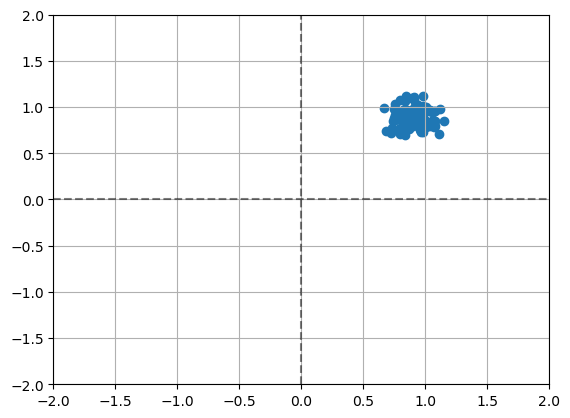

In [7]:
# i want the function that plots feature pairs. i want one column for sender and one for receiver.
plt.scatter(feats[:, 0], feats[:, 2])
plt.xlim(-2, 2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.ylim(-2, 2)
plt.grid(True)
plt.show()
